# MScFE 622: Group Work Project 1
## Team Member C and shared Step 3

We are a two-person group, so the assignment uses the roles for Team Members A and C. My work covers:

- Step 1(c): price the 20-day at-the-money Asian call;
- Step 2(a): calibrate the 60-day Bates model with the Lewis method; and
- Step 3: calibrate the CIR model and simulate future 12-month Euribor rates.

The 70-day put in Step 2(c) belongs to Team Member B and is not required for a group of two.

In [33]:
import warnings
from pathlib import Path
from time import perf_counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.interpolate import CubicSpline
from scipy.optimize import differential_evolution, least_squares
from scipy.stats import norm

In [34]:
warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

SEED = 62201
S0 = 232.90
R = 0.015
TRADING_DAYS = 250

print(
    f"Seed: {SEED} | Spot: " + "$" + f"{S0:.2f} | "
    f"Risk-free rate: {R:.2%} | "
    f"Trading days/year: {TRADING_DAYS}"
)

Seed: 62201 | Spot: $232.90 | Risk-free rate: 1.50% | Trading days/year: 250


## 1. Data and assumptions

I use the spot price $S_0=\$232.90$, an annual risk-free rate of $r=1.50\%$, and 250 trading days per year. No dividend yield was supplied, so I set $q=0$.

For an option with $d$ trading days to maturity,

$$
T=\frac{d}{250}.
$$

The option quotes and Euribor rates below come from the files supplied with the assignment. I keep them inside the notebook so it can run without separate data files.

In [35]:
DATA_FILE = "MScFE_622_Stochastic_Modeling_GWP1_Option_data.xlsx"


def find_dataset(name):
    """Find the data file in a datasets folder, or beside the notebook (e.g. Colab upload)."""
    start = Path.cwd().resolve()
    for base in (start, *start.parents):
        for candidate in (base / "datasets" / name, base / name):
            if candidate.exists():
                return candidate
    raise FileNotFoundError(
        f"{name} not found. Place it in a 'datasets' folder or beside this notebook."
    )


data_path = find_dataset(DATA_FILE)
quotes = pd.read_excel(data_path, sheet_name=0).rename(
    columns={
        "Days to maturity": "days_to_maturity",
        "Strike": "strike",
        "Price": "price",
        "Type": "type",
    }
)
quotes["type"] = quotes["type"].str.strip().str.upper()
print(f"Loaded {len(quotes)} option quotes from {data_path.name}")

# The Euribor rates are given as a table in the project brief, not in the Excel file.
euribor = pd.DataFrame(
    [
        ("1 week", 1 / 52, 0.00648),
        ("1 month", 1 / 12, 0.00679),
        ("3 months", 0.25, 0.01173),
        ("6 months", 0.50, 0.01809),
        ("12 months", 1.00, 0.02556),
    ],
    columns=["tenor", "years", "rate"],
)

assert list(quotes.columns) == ["days_to_maturity", "strike", "price", "type"]
assert len(quotes) == 30
assert set(quotes["days_to_maturity"]) == {15, 60, 120}
assert set(quotes["type"]) == {"C", "P"}
assert quotes[["days_to_maturity", "strike", "price"]].notna().all().all()
assert len(euribor) == 5

display(quotes.head(10))
display(euribor)

Loaded 30 option quotes from MScFE_622_Stochastic_Modeling_GWP1_Option_data.xlsx


,days_to_maturity,strike,price,type
0,15,227.500000,10.520000,C
1,15,230.000000,10.050000,C
2,15,232.500000,7.750000,C
3,15,235.000000,6.010000,C
4,15,237.500000,4.750000,C
5,60,227.500000,16.780000,C
6,60,230.000000,17.650000,C
7,60,232.500000,16.860000,C
8,60,235.000000,16.050000,C
9,60,237.500000,15.100000,C


,tenor,years,rate
0,1 week,0.019231,0.006480
1,1 month,0.083333,0.006790
2,3 months,0.250000,0.011730
3,6 months,0.500000,0.018090
4,12 months,1.000000,0.025560


### Checking the option quotes

Before calibration, I check the observed calls and puts against put-call parity:

$$
C_0-P_0=S_0-Ke^{-rT}.
$$

This matters because I calculate model put prices from model call prices using the same equation. If the observed quotes violate parity, no consistent model can fit every call and put exactly.

In [36]:
def quote_quality_table(frame, days):
    maturity = days / TRADING_DAYS
    selected = frame[frame["days_to_maturity"] == days]
    calls = selected[selected["type"] == "C"].set_index("strike")["price"]
    puts = selected[selected["type"] == "P"].set_index("strike")["price"]
    table = pd.concat([calls.rename("call"), puts.rename("put")], axis=1).reset_index()
    table["observed_C_minus_P"] = table["call"] - table["put"]
    table["parity_C_minus_P"] = S0 - table["strike"] * np.exp(-R * maturity)
    table["parity_error"] = table["observed_C_minus_P"] - table["parity_C_minus_P"]
    return table

In [37]:
quality_15 = quote_quality_table(quotes, 15)
quality_60 = quote_quality_table(quotes, 60)

print("15-day quote diagnostics")
display(quality_15)
print("60-day quote diagnostics")
display(quality_60)

call_60 = quality_60.sort_values("strike")["call"].to_numpy()
monotonic_violations = int(np.sum(np.diff(call_60) > 0))
parity_mse_floor_60 = float(np.mean(quality_60["parity_error"] ** 2) / 4.0)
print(f"60-day call monotonicity violations: {monotonic_violations}")
print(f"60-day maximum absolute put-call parity error: ${quality_60['parity_error'].abs().max():.4f}")
print(f"60-day parity-implied minimum possible joint MSE: {parity_mse_floor_60:.6f}")

assert monotonic_violations == 1
assert quality_60["parity_error"].abs().max() > 3.0

15-day quote diagnostics


,strike,call,put,observed_C_minus_P,parity_C_minus_P,parity_error
0,227.500000,10.520000,4.320000,6.200000,5.604658,0.595342
1,230.000000,10.050000,5.200000,4.850000,3.106907,1.743093
2,232.500000,7.750000,6.450000,1.300000,0.609156,0.690844
3,235.000000,6.010000,7.560000,-1.550000,-1.888595,0.338595
4,237.500000,4.750000,8.780000,-4.030000,-4.386346,0.356346


60-day quote diagnostics


,strike,call,put,observed_C_minus_P,parity_C_minus_P,parity_error
0,227.500000,16.780000,11.030000,5.750000,6.217528,-0.467528
1,230.000000,17.650000,12.150000,5.500000,3.726511,1.773489
2,232.500000,16.860000,13.370000,3.490000,1.235495,2.254505
3,235.000000,16.050000,14.750000,1.300000,-1.255521,2.555521
4,237.500000,15.100000,15.620000,-0.520000,-3.746537,3.226537


60-day call monotonicity violations: 1
60-day maximum absolute put-call parity error: $3.2265
60-day parity-implied minimum possible joint MSE: 1.269393


The supplied data are not fully arbitrage-consistent. The 60-day call price rises from $\$16.78$ at $K=227.50$ to $\$17.65$ at $K=230.00$, although a call price should fall as the strike rises. The largest put-call parity error is about $\$3.23$.

I keep the original quotes because the assignment asks for a regular MSE calibration. The fit error must therefore be read together with these data limitations.

## 2. Heston and Bates pricing with the Lewis method

Under the Heston model,

$$
\frac{dS_t}{S_t}=r\,dt+\sqrt{v_t}\,dW_t^S,
$$

$$
dv_t=\kappa(\theta-v_t)\,dt+\sigma_v\sqrt{v_t}\,dW_t^v,
\qquad
dW_t^S\,dW_t^v=\rho\,dt.
$$

The Bates model adds jumps to the stock price. If $J$ is the jump multiplier,

$$
\ln J\sim\mathcal{N}(\mu_J,\delta_J^2),
$$

and jumps arrive with annual intensity $\lambda_J$. A drift adjustment keeps the discounted stock price a martingale under the risk-neutral measure.

In [38]:
N_QUAD = 160
U_MAX = 160.0
raw_nodes, raw_weights = np.polynomial.legendre.leggauss(N_QUAD)
U_NODES = 0.5 * U_MAX * (raw_nodes + 1.0)
U_WEIGHTS = 0.5 * U_MAX * raw_weights


def heston_bates_return_cf(u, maturity, rate, params, jump_params=None):
    """Characteristic function of ln(S_T / S_0)."""
    kappa, theta, sigma_v, rho, v0 = np.asarray(params, dtype=float)
    iu = 1j * u

    jump_compensator = 0.0
    jump_exponent = 0.0
    if jump_params is not None:
        lambda_j, mu_j, delta_j = np.asarray(jump_params, dtype=float)
        expected_jump_minus_one = np.exp(mu_j + 0.5 * delta_j**2) - 1.0
        jump_compensator = lambda_j * expected_jump_minus_one
        jump_exponent = lambda_j * maturity * (
            np.exp(iu * mu_j - 0.5 * delta_j**2 * u**2) - 1.0
        )

    beta = kappa - rho * sigma_v * iu
    d = np.sqrt(beta**2 + sigma_v**2 * (u**2 + iu))
    g = (beta - d) / (beta + d)
    exp_minus_dt = np.exp(-d * maturity)

    c = (
        iu * (rate - jump_compensator) * maturity
        + (kappa * theta / sigma_v**2)
        * ((beta - d) * maturity - 2.0 * np.log((1.0 - g * exp_minus_dt) / (1.0 - g)))
    )
    d_loading = ((beta - d) / sigma_v**2) * (
        (1.0 - exp_minus_dt) / (1.0 - g * exp_minus_dt)
    )
    return np.exp(c + d_loading * v0 + jump_exponent)

### Lewis call price

Let $\phi_T(u)$ be the characteristic function of the log return. The Lewis call price is

$$
C_0
=S_0-
\frac{e^{-rT}\sqrt{S_0K}}{\pi}
\int_0^\infty
\frac{
\operatorname{Re}\!\left[
e^{iu\ln(S_0/K)}
\phi_T\!\left(u-\frac{i}{2}\right)
\right]
}{
u^2+\frac{1}{4}
}
\,du.
$$

I evaluate the integral with fixed Gauss-Legendre nodes. Put prices follow from

$$
P_0=C_0-S_0+Ke^{-rT}.
$$

In [39]:
def lewis_calls(strikes, maturity, params, jump_params=None):
    strikes = np.atleast_1d(np.asarray(strikes, dtype=float))
    shifted_u = U_NODES - 0.5j
    cf = heston_bates_return_cf(shifted_u, maturity, R, params, jump_params)
    oscillation = np.exp(1j * U_NODES[:, None] * np.log(S0 / strikes)[None, :])
    integrand = np.real(oscillation * cf[:, None]) / (U_NODES[:, None] ** 2 + 0.25)
    integral = U_WEIGHTS @ integrand
    calls = S0 - np.exp(-R * maturity) * np.sqrt(S0 * strikes) * integral / np.pi
    return calls

In [40]:
def black_scholes_call(strike, maturity, sigma):
    d1 = (np.log(S0 / strike) + (R + 0.5 * sigma**2) * maturity) / (sigma * np.sqrt(maturity))
    d2 = d1 - sigma * np.sqrt(maturity)
    return S0 * norm.cdf(d1) - strike * np.exp(-R * maturity) * norm.cdf(d2)


def lewis_black_scholes_call(strike, maturity, sigma):
    shifted_u = U_NODES - 0.5j
    cf = np.exp(
        1j * shifted_u * (R - 0.5 * sigma**2) * maturity
        - 0.5 * sigma**2 * shifted_u**2 * maturity
    )
    integrand = np.real(
        np.exp(1j * U_NODES * np.log(S0 / strike)) * cf
    ) / (U_NODES**2 + 0.25)
    integral = U_WEIGHTS @ integrand
    return S0 - np.exp(-R * maturity) * np.sqrt(S0 * strike) * integral / np.pi

In [41]:
bs_direct = black_scholes_call(S0, 60 / TRADING_DAYS, 0.25)
bs_lewis = lewis_black_scholes_call(S0, 60 / TRADING_DAYS, 0.25)
print(f"Lewis/Black-Scholes validation: {bs_lewis:.8f} vs {bs_direct:.8f}")
assert abs(bs_lewis - bs_direct) < 2e-5

Lewis/Black-Scholes validation: 11.77537458 vs 11.77537457


## 3. Calibration method

For $n$ observed option prices, I minimize the regular price MSE:

$$
\operatorname{MSE}(\Theta)
=
\frac{1}{n}
\sum_{j=1}^{n}
\left(
V_j^{\text{model}}(\Theta)
-
V_j^{\text{market}}
\right)^2.
$$

Each calibration starts with a seeded global search and finishes with bounded least squares. I parameterize $\sigma_v$ so that

$$
2\kappa\theta-\sigma_v^2\geq0.
$$

In [42]:
HESTON_NAMES = ["kappa", "theta", "sigma_v", "rho", "v0"]
BATES_NAMES = HESTON_NAMES + ["lambda_j", "mu_j", "delta_j"]

HESTON_BOUNDS = [
    (0.05, 15.0),
    (0.0025, 0.80),
    (0.05, 0.999),  # Feller ratio; sigma_v is derived below.
    (-0.98, 0.30),
    (0.0025, 0.80),
]
BATES_BOUNDS = HESTON_BOUNDS + [
    (0.0, 5.0),
    (-0.60, 0.25),
    (0.01, 0.80),
]

In [43]:
def market_vectors(frame, days):
    selected = frame[frame["days_to_maturity"] == days]
    calls = selected[selected["type"] == "C"].sort_values("strike")
    puts = selected[selected["type"] == "P"].sort_values("strike")
    assert np.allclose(calls["strike"], puts["strike"])
    strikes = calls["strike"].to_numpy(float)
    market = np.r_[calls["price"].to_numpy(float), puts["price"].to_numpy(float)]
    return strikes, market


def model_vector(strikes, maturity, params, with_jumps):
    if with_jumps:
        calls = lewis_calls(strikes, maturity, params[:5], params[5:])
    else:
        calls = lewis_calls(strikes, maturity, params[:5])
    puts = calls - S0 + strikes * np.exp(-R * maturity)
    return np.r_[calls, puts]


def unpack_option_calibration(raw_params, with_jumps):
    """Map a bounded Feller ratio to the reported volatility-of-variance."""
    raw_params = np.asarray(raw_params, dtype=float)
    kappa, theta, feller_ratio, rho, v0 = raw_params[:5]
    sigma_v = np.sqrt(2.0 * kappa * theta) * feller_ratio
    heston = np.array([kappa, theta, sigma_v, rho, v0])
    return np.r_[heston, raw_params[5:]] if with_jumps else heston

In [44]:
def calibrate(frame, days, with_jumps, seed, maxiter):
    strikes, market = market_vectors(frame, days)
    maturity = days / TRADING_DAYS
    bounds = BATES_BOUNDS if with_jumps else HESTON_BOUNDS

    def residuals(raw_params):
        params = unpack_option_calibration(raw_params, with_jumps)
        values = model_vector(strikes, maturity, params, with_jumps)
        if not np.all(np.isfinite(values)):
            return np.full_like(market, 1e6)
        return values - market

    def mse(raw_params):
        errors = residuals(raw_params)
        return float(np.mean(errors**2))

    started = perf_counter()
    global_fit = differential_evolution(
        mse,
        bounds,
        seed=seed,
        maxiter=maxiter,
        popsize=12,
        tol=1e-8,
        atol=1e-8,
        polish=False,
        workers=1,
        updating="immediate",
    )
    lower = np.array([item[0] for item in bounds])
    upper = np.array([item[1] for item in bounds])
    local_fit = least_squares(
        residuals,
        np.clip(global_fit.x, lower + 1e-10, upper - 1e-10),
        bounds=(lower, upper),
        max_nfev=5_000,
        ftol=1e-12,
        xtol=1e-12,
        gtol=1e-12,
    )
    elapsed = perf_counter() - started
    calibrated_params = unpack_option_calibration(local_fit.x, with_jumps)
    fitted = model_vector(strikes, maturity, calibrated_params, with_jumps)
    errors = fitted - market
    metrics = {
        "mse": float(np.mean(errors**2)),
        "rmse": float(np.sqrt(np.mean(errors**2))),
        "mae": float(np.mean(np.abs(errors))),
        "max_abs_error": float(np.max(np.abs(errors))),
        "elapsed_seconds": elapsed,
        "global_iterations": int(global_fit.nit),
        "local_success": bool(local_fit.success),
        "local_message": local_fit.message,
    }
    return calibrated_params, strikes, market, fitted, metrics

In [45]:
def parameter_table(values, with_jumps):
    names = BATES_NAMES if with_jumps else HESTON_NAMES
    table = pd.DataFrame({"parameter": names, "estimate": values})
    kappa, theta, sigma_v = values[:3]
    feller_margin = 2.0 * kappa * theta - sigma_v**2
    return table, feller_margin


def fit_table(strikes, market, fitted):
    count = len(strikes)
    return pd.DataFrame(
        {
            "type": ["Call"] * count + ["Put"] * count,
            "strike": np.r_[strikes, strikes],
            "market": market,
            "model": fitted,
            "error": fitted - market,
        }
    )


def plot_option_fit(table, title, output_name):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
    for axis, option_type in zip(axes, ["Call", "Put"]):
        current = table[table["type"] == option_type]
        axis.plot(current["strike"], current["market"], "o-", label="Market")
        axis.plot(current["strike"], current["model"], "s--", label="Model")
        axis.set_title(option_type)
        axis.set_xlabel("Strike (USD)")
        axis.grid(alpha=0.25)
    axes[0].set_ylabel("Option price (USD)")
    axes[1].legend(frameon=False)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

## 4. Step 1(c): 20-day Asian call

The final Asian price should use Team Member A's approved 15-day Heston calibration. Those values were not available when I prepared this notebook, so I use a separate 15-day Lewis calibration as a temporary fallback.

The expected parameter order from Team Member A is

$$
(\kappa,\theta,\sigma_v,\rho,v_0).
$$

In [46]:
TEAM_A_HESTON_PARAMS = None  # Replace with np.array([...]) after teammate handoff.

fallback_heston, strikes_15, market_15, fitted_15, heston_metrics = calibrate(
    quotes, days=15, with_jumps=False, seed=SEED, maxiter=90
)
heston_table, heston_feller = parameter_table(fallback_heston, with_jumps=False)
heston_fit = fit_table(strikes_15, market_15, fitted_15)

if TEAM_A_HESTON_PARAMS is None:
    asian_heston_params = fallback_heston
    heston_source = "independent reproducible fallback (replace with Team Member A final values)"
else:
    asian_heston_params = np.asarray(TEAM_A_HESTON_PARAMS, dtype=float)
    assert asian_heston_params.shape == (5,)
    heston_source = "Team Member A final Lewis calibration"

Heston parameter source: independent reproducible fallback (replace with Team Member A final values)


,parameter,estimate
0,kappa,4.365365
1,theta,0.216947
2,sigma_v,1.374890
3,rho,-0.980000
4,v0,0.086222


,mse,rmse,mae,max_abs_error,elapsed_seconds,global_iterations,local_success,local_message
0,0.246085,0.496069,0.372422,1.194073,4.916357,90,True,`xtol` termination condition is satisfied.


Feller margin 2*kappa*theta - sigma_v^2: 0.003786


,type,strike,market,model,error
0,Call,227.500000,10.520000,10.509442,-0.010558
1,Call,230.000000,10.050000,8.855927,-1.194073
2,Call,232.500000,7.750000,7.318753,-0.431247
3,Call,235.000000,6.010000,5.908951,-0.101049
4,Call,237.500000,4.750000,4.635212,-0.114788
5,Put,227.500000,4.320000,4.904784,0.584784
6,Put,230.000000,5.200000,5.749020,0.549020
7,Put,232.500000,6.450000,6.709597,0.259597
8,Put,235.000000,7.560000,7.797546,0.237546
9,Put,237.500000,8.780000,9.021558,0.241558


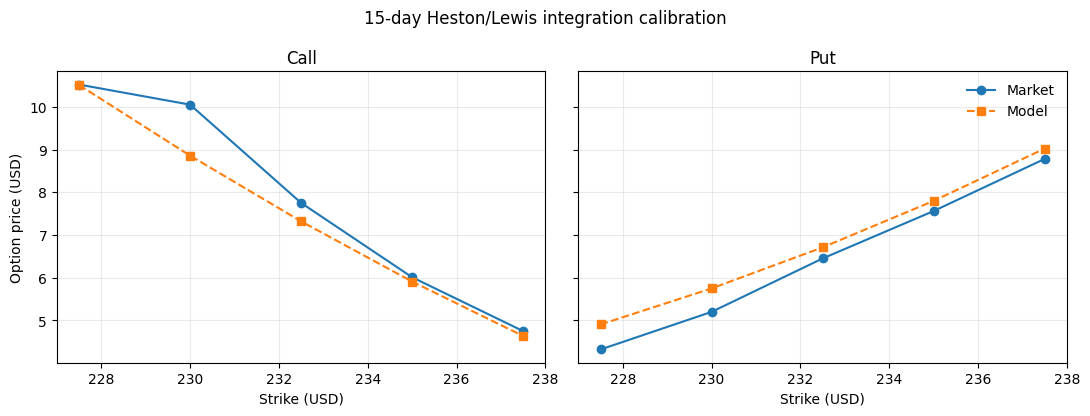

In [47]:
print(f"Heston parameter source: {heston_source}")
display(heston_table)
display(pd.DataFrame([heston_metrics]))
print(f"Feller margin 2*kappa*theta - sigma_v^2: {heston_feller:.6f}")
display(heston_fit)
assert heston_metrics["local_success"]

plot_option_fit(
    heston_fit,
    "15-day Heston/Lewis integration calibration",
    "step1_heston_15d_fit.png",
)

The arithmetic average includes today's stock price and the next 20 daily prices:

$$
\bar{S}
=
\frac{1}{21}
\sum_{t=0}^{20}S_t.
$$

The option is at the money, so $K=S_0$. Its payoff and fair value are

$$
\text{Payoff}=\max(\bar{S}-K,0),
$$

$$
V_0=e^{-rT}\mathbb{E}^{\mathbb{Q}}[\text{Payoff}].
$$

The 4% bank fee gives

$$
V_{\text{client}}=1.04V_0.
$$

In [48]:
def price_asian_call_heston(
    params,
    paths=200_000,
    days=20,
    seed=SEED + 1,
):
    """Daily monitored ATM arithmetic Asian call with antithetic sampling."""
    assert paths % 2 == 0
    kappa, theta, sigma_v, rho, v0 = np.asarray(params, dtype=float)
    half = paths // 2
    rng = np.random.default_rng(seed)
    dt = 1.0 / TRADING_DAYS

    stock = np.full(paths, S0)
    variance = np.full(paths, v0)
    running_sum = stock.copy()  # Includes S0 exactly as required by the brief.
    checkpoints = {1, 2, 5, 10, 20}
    convergence = []

    for day in range(1, days + 1):
        z_v_half = rng.standard_normal(half)
        z_i_half = rng.standard_normal(half)
        z_v = np.r_[z_v_half, -z_v_half]
        z_i = np.r_[z_i_half, -z_i_half]
        z_s = rho * z_v + np.sqrt(1.0 - rho**2) * z_i

        v_positive = np.maximum(variance, 0.0)
        stock *= np.exp((R - 0.5 * v_positive) * dt + np.sqrt(v_positive * dt) * z_s)
        variance = np.maximum(
            variance
            + kappa * (theta - v_positive) * dt
            + sigma_v * np.sqrt(v_positive * dt) * z_v,
            0.0,
        )
        running_sum += stock

        if day in checkpoints:
            partial_average = running_sum / (day + 1)
            partial_payoff = np.maximum(partial_average - S0, 0.0)
            paired = 0.5 * (partial_payoff[:half] + partial_payoff[half:])
            discount = np.exp(-R * day / TRADING_DAYS)
            estimate = discount * paired.mean()
            standard_error = discount * paired.std(ddof=1) / np.sqrt(half)
            convergence.append((day, estimate, standard_error))

    average = running_sum / (days + 1)
    payoff = np.maximum(average - S0, 0.0)
    paired_payoff = 0.5 * (payoff[:half] + payoff[half:])
    discount = np.exp(-R * days / TRADING_DAYS)
    fair_value = discount * paired_payoff.mean()
    standard_error = discount * paired_payoff.std(ddof=1) / np.sqrt(half)
    confidence_interval = (
        fair_value - 1.96 * standard_error,
        fair_value + 1.96 * standard_error,
    )
    client_price = 1.04 * fair_value
    return {
        "fair_value": fair_value,
        "standard_error": standard_error,
        "ci_low": confidence_interval[0],
        "ci_high": confidence_interval[1],
        "client_price": client_price,
        "paths": paths,
        "monitoring_points": days + 1,
        "positive_payoff_probability": float(np.mean(payoff > 0.0)),
        "convergence": pd.DataFrame(convergence, columns=["day", "estimate", "standard_error"]),
        "payoff_sample": payoff[:20_000],
    }

In [49]:
asian = price_asian_call_heston(asian_heston_params)
asian_summary = pd.DataFrame(
    [
        {
            key: value
            for key, value in asian.items()
            if key not in {"convergence", "payoff_sample"}
        }
    ]
)
display(asian_summary)
display(asian["convergence"])

assert asian["fair_value"] > 0
assert asian["standard_error"] < 0.05
assert np.isclose(asian["client_price"], 1.04 * asian["fair_value"])

,fair_value,standard_error,ci_low,ci_high,client_price,paths,monitoring_points,positive_payoff_probability
0,4.617106,0.006853,4.603674,4.630537,4.801790,200000,21,0.565685


,day,estimate,standard_error
0,1,0.868686,0.002102
1,2,1.298539,0.002964
2,5,2.170521,0.004370
3,10,3.170757,0.005552
4,20,4.617106,0.006853


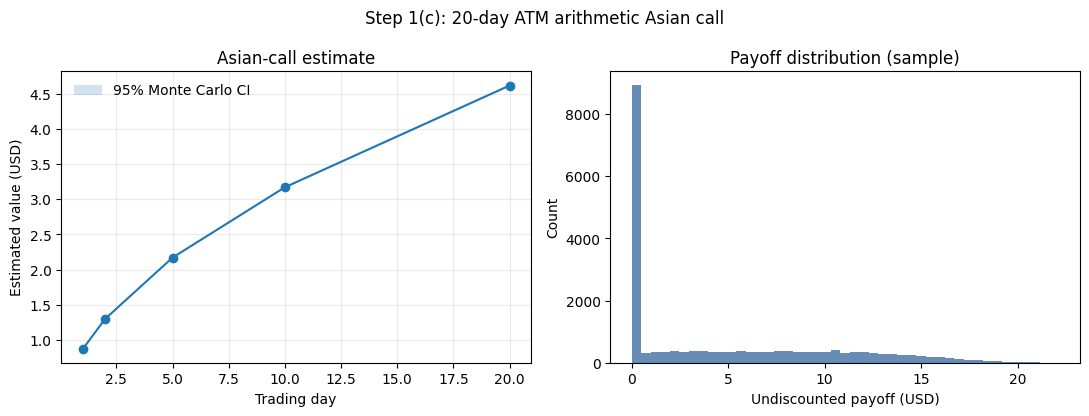

In [50]:
convergence = asian["convergence"].copy()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(convergence["day"], convergence["estimate"], "o-")
axes[0].fill_between(
    convergence["day"],
    convergence["estimate"] - 1.96 * convergence["standard_error"],
    convergence["estimate"] + 1.96 * convergence["standard_error"],
    alpha=0.2,
    label="95% Monte Carlo CI",
)
axes[0].set(xlabel="Trading day", ylabel="Estimated value (USD)", title="Asian-call estimate")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.25)
axes[1].hist(asian["payoff_sample"], bins=45, color="#4C78A8", alpha=0.85)
axes[1].set(xlabel="Undiscounted payoff (USD)", ylabel="Count", title="Payoff distribution (sample)")
fig.suptitle("Step 1(c): 20-day ATM arithmetic Asian call")
fig.tight_layout()
plt.show()

The fair value is the discounted average payoff across the simulated paths. The 95% interval only measures Monte Carlo sampling error; it does not include model or calibration uncertainty.

The fee is 4% of the fair value, not an additional $\$4$. The Asian price remains provisional until Team Member A's final Heston parameters are inserted and the notebook is run again.

## 5. Step 2(a): 60-day Bates calibration

I fit the eight Bates parameters

$$
(\kappa,\theta,\sigma_v,\rho,v_0,\lambda_J,\mu_J,\delta_J)
$$

to the five calls and five puts with 60 days to maturity. The model uses the Lewis integral and regular price MSE described above.

In [51]:
bates_params, strikes_60, market_60, fitted_60, bates_metrics = calibrate(
    quotes, days=60, with_jumps=True, seed=SEED + 2, maxiter=150
)
bates_table, bates_feller = parameter_table(bates_params, with_jumps=True)
bates_fit = fit_table(strikes_60, market_60, fitted_60)

display(bates_table)
display(pd.DataFrame([bates_metrics]))
print(f"Feller margin 2*kappa*theta - sigma_v^2: {bates_feller:.6f}")
display(bates_fit)
assert bates_metrics["local_success"]

,parameter,estimate
0,kappa,4.187824
1,theta,0.002500
2,sigma_v,0.016364
3,rho,-0.925688
4,v0,0.002500
5,lambda_j,1.879535
6,mu_j,0.213505
7,delta_j,0.010000


,mse,rmse,mae,max_abs_error,elapsed_seconds,global_iterations,local_success,local_message
0,1.335154,1.155489,1.050763,1.871775,10.514923,150,True,`ftol` termination condition is satisfied.


Feller margin 2*kappa*theta - sigma_v^2: 0.020671


,type,strike,market,model,error
0,Call,227.500000,16.780000,17.362554,0.582554
1,Call,230.000000,17.650000,16.458058,-1.191942
2,Call,232.500000,16.860000,15.553654,-1.306346
3,Call,235.000000,16.050000,14.649340,-1.400660
4,Call,237.500000,15.100000,13.745238,-1.354762
5,Put,227.500000,11.030000,11.145027,0.115027
6,Put,230.000000,12.150000,12.731546,0.581546
7,Put,232.500000,13.370000,14.318158,0.948158
8,Put,235.000000,14.750000,15.904861,1.154861
9,Put,237.500000,15.620000,17.491775,1.871775


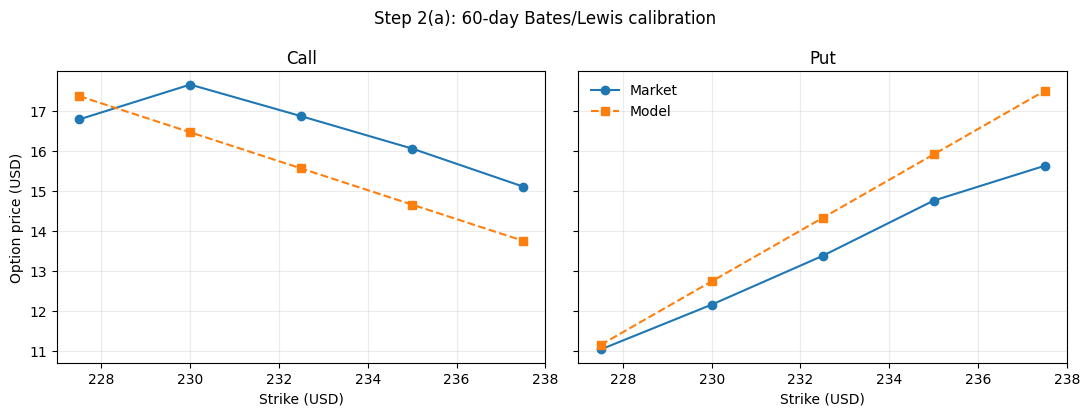

In [52]:
plot_option_fit(
    bates_fit,
    "Step 2(a): 60-day Bates/Lewis calibration",
    "step2_bates_60d_fit.png",
)

### Parameter stability check

Eight parameters are being estimated from only ten prices at one maturity. I repeat the search with a different seed.

If two parameter sets give nearly the same prices and MSE, the fitted price curve is stable but the individual parameters are not uniquely identified.

In [53]:
# A second seeded global fit is a small identifiability check: similar pricing
# error with different parameters is evidence that this sparse/noisy slice does
# not uniquely determine all eight Bates parameters.
bates_params_check, _, _, fitted_60_check, bates_metrics_check = calibrate(
    quotes, days=60, with_jumps=True, seed=SEED + 3, maxiter=90
)
bates_stability = pd.DataFrame(
    {
        "parameter": BATES_NAMES,
        "primary_fit": bates_params,
        "second_seed_fit": bates_params_check,
        "absolute_difference": np.abs(bates_params - bates_params_check),
    }
)
display(bates_stability)
display(
    pd.DataFrame(
        [
            {"fit": "primary", **bates_metrics},
            {"fit": "second seed", **bates_metrics_check},
        ]
    )[["fit", "mse", "rmse", "mae", "max_abs_error"]]
)

assert bates_metrics["rmse"] < 1.5
assert bates_metrics["mse"] >= parity_mse_floor_60
assert np.max(np.abs(fitted_60 - fitted_60_check)) < 0.25

,parameter,primary_fit,second_seed_fit,absolute_difference
0,kappa,4.187824,1.773978,2.413846
1,theta,0.002500,0.002500,0.000000
2,sigma_v,0.016364,0.078601,0.062237
3,rho,-0.925688,-0.980000,0.054312
4,v0,0.002500,0.002568,0.000068
5,lambda_j,1.879535,1.877438,0.002096
6,mu_j,0.213505,0.213600,0.000095
7,delta_j,0.010000,0.010000,0.000000


,fit,mse,rmse,mae,max_abs_error
0,primary,1.335154,1.155489,1.050763,1.871775
1,second seed,1.335116,1.155472,1.049903,1.876158


The two searches produce similar prices and fit errors, but some variance parameters change noticeably. This shows that the price curve is better identified than the full parameter vector.

Team Member A should compare the Lewis and Carr-Madan methods mainly through model prices and RMSE. With the same characteristic function and accurate numerical settings, the two methods should give similar prices. Large price differences would suggest an implementation mismatch.

## 6. Step 3(a): Euribor curve and CIR calibration

I treat the supplied Euribor rates as annualized zero rates. A natural cubic spline gives weekly rates for weeks 1 through 52.

The weekly points form a smooth calibration grid. They are not 52 independent market observations; the original information still comes from five tenors.

In [54]:
weeks = np.arange(1, 53)
weekly_years = weeks / 52.0
spline = CubicSpline(euribor["years"], euribor["rate"], bc_type="natural")
weekly_market_rates = spline(weekly_years)

assert np.isclose(weekly_market_rates[0], euribor.iloc[0]["rate"])
assert np.isclose(weekly_market_rates[-1], euribor.iloc[-1]["rate"])
assert np.all(weekly_market_rates > 0)

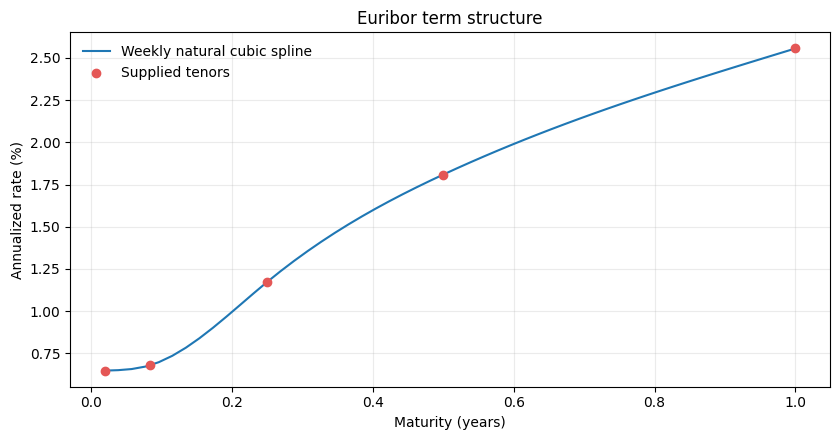

In [55]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(weekly_years, weekly_market_rates * 100, label="Weekly natural cubic spline")
ax.scatter(euribor["years"], euribor["rate"] * 100, color="#E45756", zorder=3, label="Supplied tenors")
ax.set(xlabel="Maturity (years)", ylabel="Annualized rate (%)", title="Euribor term structure")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

### CIR model

The CIR short rate follows

$$
dr_t=\kappa(\theta-r_t)\,dt+\sigma\sqrt{r_t}\,dW_t.
$$

Its zero-coupon bond price has the form

$$
P(0,T)=A(T)e^{-B(T)r_0},
$$

and the continuously compounded zero rate is

$$
y(0,T)=-\frac{\ln P(0,T)}{T}.
$$

I fix $r_0=0.648\%$, the supplied one-week Euribor rate, and calibrate $\kappa$, $\theta$, and $\sigma$ to the weekly spline.

In [56]:
def cir_zero_yield(maturity, short_rate, kappa, theta, sigma):
    maturity = np.asarray(maturity, dtype=float)
    gamma = np.sqrt(kappa**2 + 2.0 * sigma**2)
    exp_gamma_t = np.exp(gamma * maturity)
    denominator = (gamma + kappa) * (exp_gamma_t - 1.0) + 2.0 * gamma
    b_loading = 2.0 * (exp_gamma_t - 1.0) / denominator
    log_a = (2.0 * kappa * theta / sigma**2) * (
        np.log(2.0 * gamma)
        + 0.5 * (kappa + gamma) * maturity
        - np.log(denominator)
    )
    log_bond = log_a - b_loading * np.asarray(short_rate, dtype=float)
    return -log_bond / maturity


R0 = float(euribor.iloc[0]["rate"])
CIR_BOUNDS = [(0.01, 15.0), (0.001, 0.20), (0.05, 0.999)]


def unpack_cir_calibration(raw_params):
    kappa, theta, feller_ratio = np.asarray(raw_params, dtype=float)
    sigma = np.sqrt(2.0 * kappa * theta) * feller_ratio
    return np.array([kappa, theta, sigma])


def cir_residuals(raw_params):
    params = unpack_cir_calibration(raw_params)
    return (
        cir_zero_yield(weekly_years, R0, *params) - weekly_market_rates
    ) * 10_000.0  # basis points

In [57]:
cir_global = differential_evolution(
    lambda params: float(np.mean(cir_residuals(params) ** 2)),
    CIR_BOUNDS,
    seed=SEED + 4,
    maxiter=180,
    popsize=15,
    tol=1e-10,
    polish=False,
)
cir_lower = np.array([bound[0] for bound in CIR_BOUNDS])
cir_upper = np.array([bound[1] for bound in CIR_BOUNDS])
cir_local = least_squares(
    cir_residuals,
    cir_global.x,
    bounds=(cir_lower, cir_upper),
    ftol=1e-13,
    xtol=1e-13,
    gtol=1e-13,
    max_nfev=10_000,
)
cir_params = unpack_cir_calibration(cir_local.x)
cir_model_rates = cir_zero_yield(weekly_years, R0, *cir_params)
cir_error_bps = (cir_model_rates - weekly_market_rates) * 10_000.0
cir_rmse_bps = float(np.sqrt(np.mean(cir_error_bps**2)))
cir_feller = 2.0 * cir_params[0] * cir_params[1] - cir_params[2] ** 2

In [58]:
cir_table = pd.DataFrame(
    {
        "parameter": ["kappa", "theta", "sigma", "r0"],
        "estimate": [*cir_params, R0],
    }
)
display(cir_table)
print(f"Weekly-yield RMSE: {cir_rmse_bps:.4f} basis points")
print(f"Feller margin 2*kappa*theta - sigma^2: {cir_feller:.6f}")

assert cir_local.success
assert cir_rmse_bps < 15.0

,parameter,estimate
0,kappa,0.696370
1,theta,0.077506
2,sigma,0.328222
3,r0,0.006480


Weekly-yield RMSE: 7.8486 basis points
Feller margin 2*kappa*theta - sigma^2: 0.000216


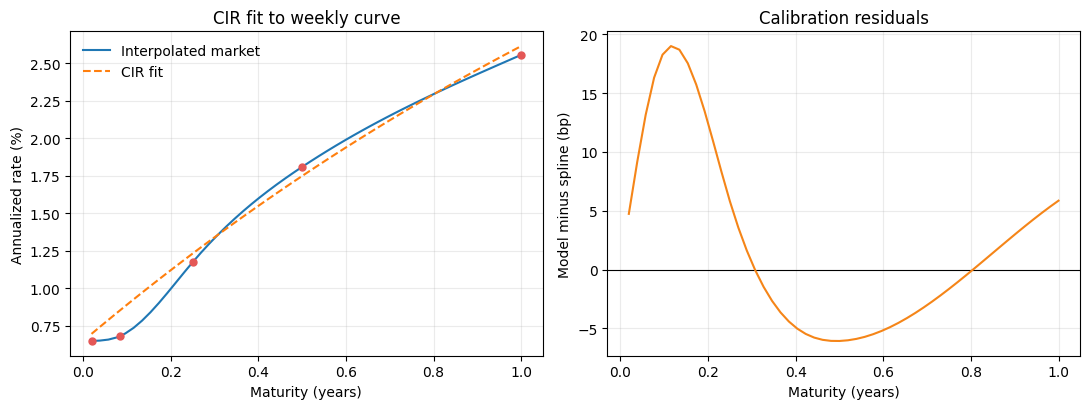

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(weekly_years, weekly_market_rates * 100, label="Interpolated market")
axes[0].plot(weekly_years, cir_model_rates * 100, "--", label="CIR fit")
axes[0].scatter(euribor["years"], euribor["rate"] * 100, s=25, color="#E45756", zorder=3)
axes[0].set(xlabel="Maturity (years)", ylabel="Annualized rate (%)", title="CIR fit to weekly curve")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.25)
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].plot(weekly_years, cir_error_bps, color="#F58518")
axes[1].set(xlabel="Maturity (years)", ylabel="Model minus spline (bp)", title="Calibration residuals")
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

The fitted curve follows the upward shape of the supplied Euribor rates. The RMSE measures the difference between the CIR yields and the weekly spline in basis points.

This is a risk-neutral term-structure calibration. It is not a historical estimate of real-world interest-rate behaviour.

## 7. Step 3(b): 100,000 daily rate scenarios

I simulate 100,000 paths for 250 trading days. The CIR process is sampled from its exact noncentral chi-square transition, which keeps the short rate non-negative without an Euler approximation.

At each day, I convert the simulated short rate into the model's one-year zero rate. I use this as the 12-month Euribor proxy.

In [60]:
def simulate_cir_12m_rates(
    params,
    short_rate_0,
    scenarios=100_000,
    days=TRADING_DAYS,
    seed=SEED + 5,
):
    kappa, theta, sigma = np.asarray(params, dtype=float)
    rng = np.random.default_rng(seed)
    dt = 1.0 / TRADING_DAYS
    decay = np.exp(-kappa * dt)
    scale = sigma**2 * (1.0 - decay) / (4.0 * kappa)
    degrees_freedom = 4.0 * kappa * theta / sigma**2

    short_rates = np.full(scenarios, short_rate_0)
    sample_count = 100
    sample_paths = np.empty((days + 1, sample_count))
    mean_path = np.empty(days + 1)
    low_path = np.empty(days + 1)
    high_path = np.empty(days + 1)

    initial_12m = cir_zero_yield(1.0, short_rates, kappa, theta, sigma)
    sample_paths[0] = initial_12m[:sample_count]
    mean_path[0] = initial_12m.mean()
    low_path[0], high_path[0] = np.quantile(initial_12m, [0.025, 0.975])

    for day in range(1, days + 1):
        noncentrality = (
            4.0 * kappa * decay * short_rates
            / (sigma**2 * (1.0 - decay))
        )
        short_rates = scale * rng.noncentral_chisquare(degrees_freedom, noncentrality)
        rate_12m = cir_zero_yield(1.0, short_rates, kappa, theta, sigma)
        sample_paths[day] = rate_12m[:sample_count]
        mean_path[day] = rate_12m.mean()
        low_path[day], high_path[day] = np.quantile(rate_12m, [0.025, 0.975])

    terminal_12m = cir_zero_yield(1.0, short_rates, kappa, theta, sigma)
    expected_short_rate = theta + (short_rate_0 - theta) * np.exp(-kappa)
    analytical_expected_12m = float(cir_zero_yield(1.0, expected_short_rate, kappa, theta, sigma))
    summary = {
        "scenarios": scenarios,
        "confidence_level": 0.95,
        "current_market_12m": float(euribor.iloc[-1]["rate"]),
        "current_model_12m": float(mean_path[0]),
        "expected_12m_in_one_year": float(terminal_12m.mean()),
        "analytical_expected_12m_in_one_year": analytical_expected_12m,
        "terminal_95pct_low": float(np.quantile(terminal_12m, 0.025)),
        "terminal_95pct_high": float(np.quantile(terminal_12m, 0.975)),
        "daily_envelope_min": float(low_path.min()),
        "daily_envelope_max": float(high_path.max()),
    }
    paths = pd.DataFrame(
        {
            "day": np.arange(days + 1),
            "mean": mean_path,
            "low_2_5": low_path,
            "high_97_5": high_path,
        }
    )
    return summary, paths, sample_paths, terminal_12m

In [61]:
cir_mc_summary, cir_paths, cir_sample_paths, cir_terminal = simulate_cir_12m_rates(
    cir_params,
    R0,
)
display(pd.DataFrame([cir_mc_summary]))

assert cir_mc_summary["scenarios"] == 100_000
assert np.min(cir_terminal) >= 0.0
assert abs(
    cir_mc_summary["expected_12m_in_one_year"]
    - cir_mc_summary["analytical_expected_12m_in_one_year"]
) < 5e-4

,scenarios,confidence_level,current_market_12m,current_model_12m,expected_12m_in_one_year,analytical_expected_12m_in_one_year,terminal_95pct_low,terminal_95pct_high,daily_envelope_min,daily_envelope_max
0,100000,0.950000,0.025560,0.026146,0.051520,0.051487,0.022313,0.132077,0.021820,0.132077


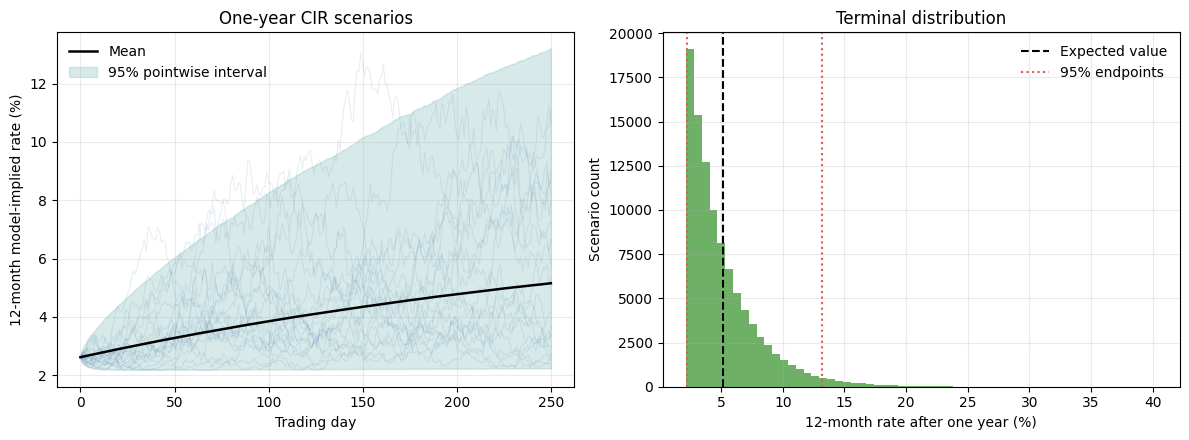

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
days_axis = cir_paths["day"].to_numpy()
for column in range(20):
    axes[0].plot(days_axis, cir_sample_paths[:, column] * 100, color="#4C78A8", alpha=0.12, linewidth=0.8)
axes[0].plot(days_axis, cir_paths["mean"] * 100, color="black", linewidth=1.8, label="Mean")
axes[0].fill_between(
    days_axis,
    cir_paths["low_2_5"].to_numpy() * 100,
    cir_paths["high_97_5"].to_numpy() * 100,
    color="#72B7B2",
    alpha=0.28,
    label="95% pointwise interval",
)
axes[0].set(xlabel="Trading day", ylabel="12-month model-implied rate (%)", title="One-year CIR scenarios")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.25)
axes[1].hist(cir_terminal * 100, bins=60, color="#54A24B", alpha=0.85)
axes[1].axvline(cir_mc_summary["expected_12m_in_one_year"] * 100, color="black", linestyle="--", label="Expected value")
axes[1].axvline(cir_mc_summary["terminal_95pct_low"] * 100, color="#E45756", linestyle=":")
axes[1].axvline(cir_mc_summary["terminal_95pct_high"] * 100, color="#E45756", linestyle=":", label="95% endpoints")
axes[1].set(xlabel="12-month rate after one year (%)", ylabel="Scenario count", title="Terminal distribution")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

The interval is a 95% risk-neutral scenario interval. It is not a guaranteed range and it is not a real-world economic forecast.

If the expected future 12-month rate is above today's 2.556%, fixed future cash flows will be discounted more heavily. With other inputs unchanged, a higher risk-free rate generally increases call values and reduces put values. The exact effect still depends on the payoff, spot price, volatility, and the full yield curve.

## 8. Summary of results

The table below collects the main answers from my part of the project. Values are rounded for reporting; full-precision values remain in the earlier output cells.

In [63]:
summary = pd.DataFrame(
    [
        (
            "Step 1(c)",
            "Asian call fair value",
            "$" + f"{asian['fair_value']:.4f}",
        ),
        (
            "Step 1(c)",
            "Client price after 4% fee",
            "$" + f"{asian['client_price']:.4f}",
        ),
        (
            "Step 2(a)",
            "Bates calibration RMSE",
            "$" + f"{bates_metrics['rmse']:.4f}",
        ),
        (
            "Step 3(a)",
            "CIR curve RMSE",
            f"{cir_rmse_bps:.4f} bp",
        ),
        (
            "Step 3(b)",
            "Expected 12-month rate in one year",
            f"{cir_mc_summary['expected_12m_in_one_year']:.4%}",
        ),
        (
            "Step 3(b)",
            "95% terminal interval",
            (
                f"{cir_mc_summary['terminal_95pct_low']:.4%}"
                " to "
                f"{cir_mc_summary['terminal_95pct_high']:.4%}"
            ),
        ),
    ],
    columns=["Task", "Result", "Value"],
)
display(summary)

,Task,Result,Value
0,Step 1(c),Asian call fair value,$4.6171
1,Step 1(c),Client price after 4% fee,$4.8018
2,Step 2(a),Bates calibration RMSE,$1.1555
3,Step 3(a),CIR curve RMSE,7.8486 bp
4,Step 3(b),Expected 12-month rate in one year,5.1520%
5,Step 3(b),95% terminal interval,2.2313% to 13.2077%


## Before the final group submission

1. Replace the fallback Heston vector with Team Member A's final Step 1 calibration and run all cells again.
2. Add Team Member A's Step 1(a) and Step 2(b) work to the group notebook.
3. Compare Lewis and Carr-Madan prices and RMSE using the same inputs.
4. Export the final notebook to HTML and place both files in the submission ZIP.
5. Keep the report PDF separate from the ZIP.

## References

Bates, David S. “Jumps and Stochastic Volatility: Exchange Rate Processes Implicit in Deutsche Mark Options.” *The Review of Financial Studies*, vol. 9, no. 1, 1996, pp. 69–107.

Cox, John C., Jonathan E. Ingersoll, Jr., and Stephen A. Ross. “A Theory of the Term Structure of Interest Rates.” *Econometrica*, vol. 53, no. 2, 1985, pp. 385–407.

Heston, Steven L. “A Closed-Form Solution for Options with Stochastic Volatility with Applications to Bond and Currency Options.” *The Review of Financial Studies*, vol. 6, no. 2, 1993, pp. 327–343.

Lewis, Alan L. “A Simple Option Formula for General Jump-Diffusion and Other Exponential Lévy Processes.” 2001.